In [3]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
from datetime import datetime
import yaml

In [25]:
control_key = "is_control"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "plate_well"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

condition_keys = "perturbation"
data_origin = "Sciplex3_test_42_0.2_True_X_pca_100_None"  #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"

data_origin_ot = data_origin

In [21]:
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad",backed='r')
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad",backed='r')
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad",backed='r')
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 163 × 2000 backed at 'data/processed/Sciplex3_test_42_0.2_True_X_pca_100_None_control.h5ad'
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cell_line_idx', 'dose_value_scaled', 'time_scaled', 'condition_combined'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cov_config', 'covariate_info', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'
AnnData object with n_obs × n_vars = 6000 × 2000 backed at 'data/processed/Sciplex3_test_42_0.2_True_X_pca_100_None_train.h5ad'
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', '

In [20]:
adata_control.uns

{'cov_config': {'cell_line': {'condition_combined_from': 'both',
   'contain_in_condition_combined_keys': np.True_,
   'control_ot': 'groupwise',
   'model_input_from': 'control',
   'perturbed_ot': 'groupwise',
   'type': 'categorical',
   'use_in_model': np.True_},
  'dose_value': {'condition_combined_from': 'perturbed',
   'contain_in_condition_combined_keys': np.True_,
   'control_ot': 'global',
   'model_input_from': 'condition_combined_keys',
   'perturbed_ot': 'groupwise',
   'type': 'continuous',
   'use_in_model': np.True_},
  'time': {'condition_combined_from': 'both',
   'contain_in_condition_combined_keys': np.True_,
   'control_ot': 'groupwise',
   'model_input_from': 'condition_combined_keys',
   'perturbed_ot': 'groupwise',
   'type': 'continuous',
   'use_in_model': np.True_}},
 'covariate_info': {'categorical_mappings': {'cell_line': {'A549': np.int64(0),
    'K562': np.int64(1),
    'MCF7': np.int64(2)}},
  'combined_logic': {'base': 'perturbation',
   'constituents':

## training

In [35]:
from src.training import pre_compute_wfr_ot, seed_everything
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/utils.py:161: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  control_gb = adata_control.obs.groupby(control_groups_keys)
/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/utils.py:162: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  treated_gb = adata_treated.obs.groupby(perturbed_groups_keys)
  0%|          | 0/10 [00:00<?, ?it/s]

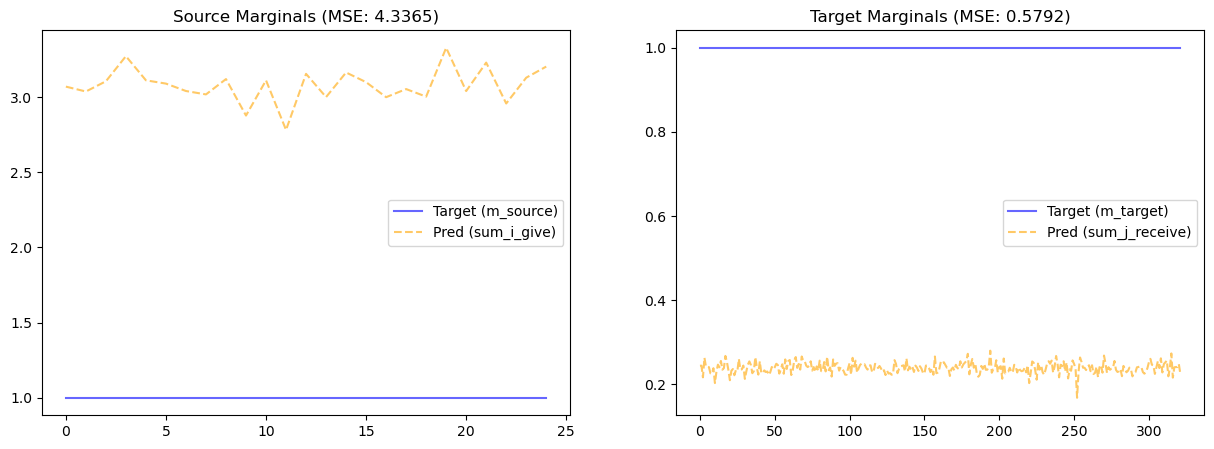

 10%|█         | 1/10 [00:00<00:03,  2.27it/s]

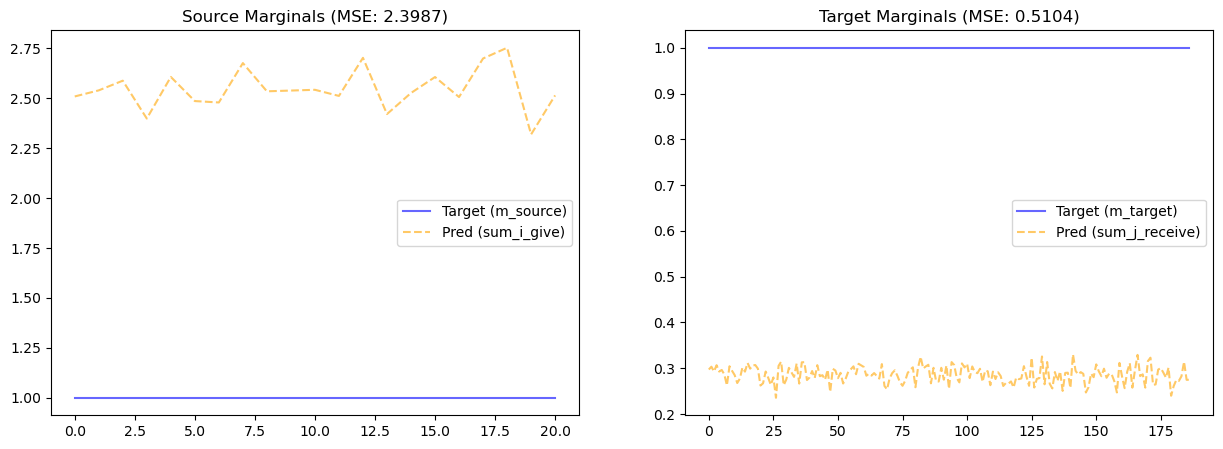

 20%|██        | 2/10 [00:00<00:02,  2.97it/s]

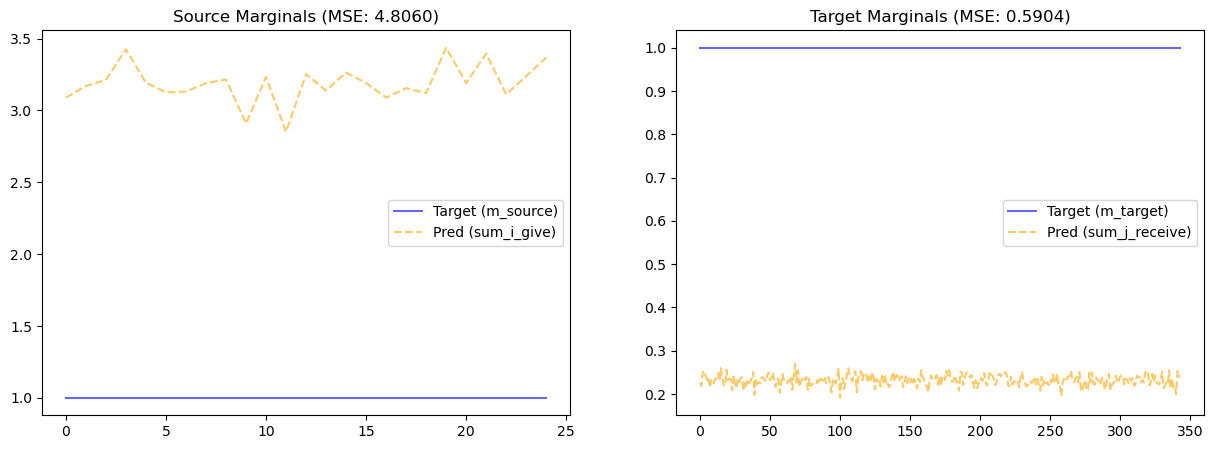

 30%|███       | 3/10 [00:01<00:02,  2.51it/s]

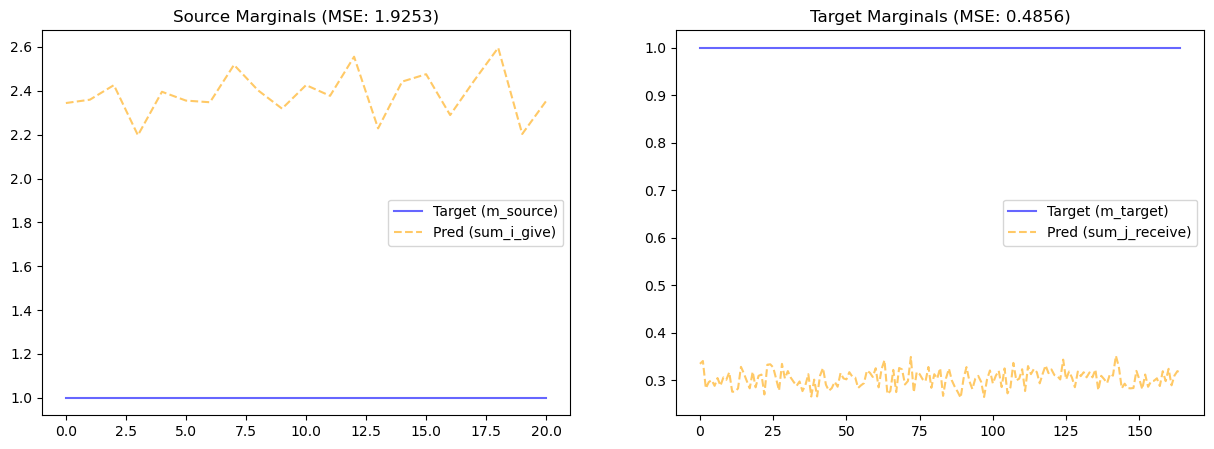

 40%|████      | 4/10 [00:01<00:02,  2.93it/s]

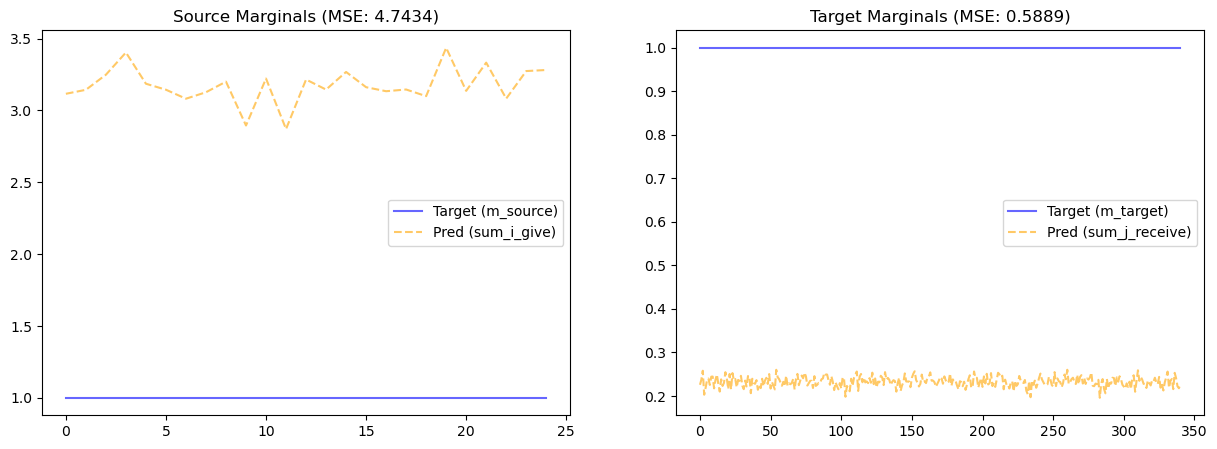

 50%|█████     | 5/10 [00:01<00:01,  3.13it/s]

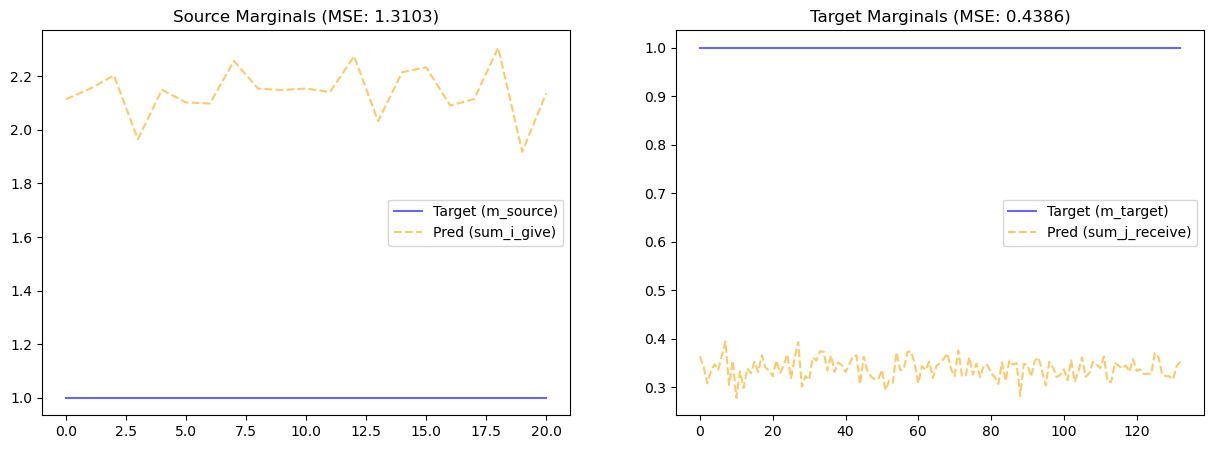

 60%|██████    | 6/10 [00:01<00:01,  3.39it/s]

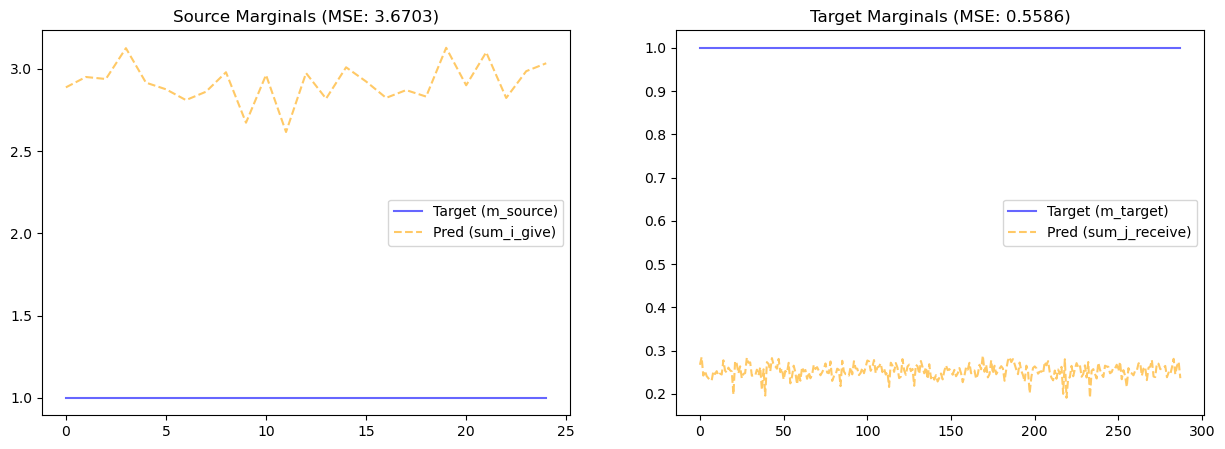

 70%|███████   | 7/10 [00:02<00:00,  3.52it/s]

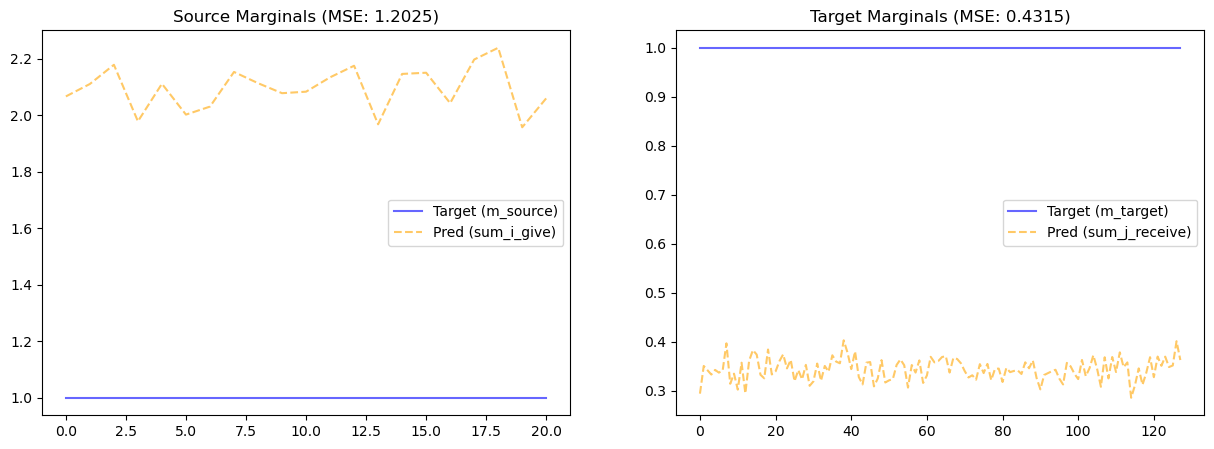

 80%|████████  | 8/10 [00:02<00:00,  3.67it/s]

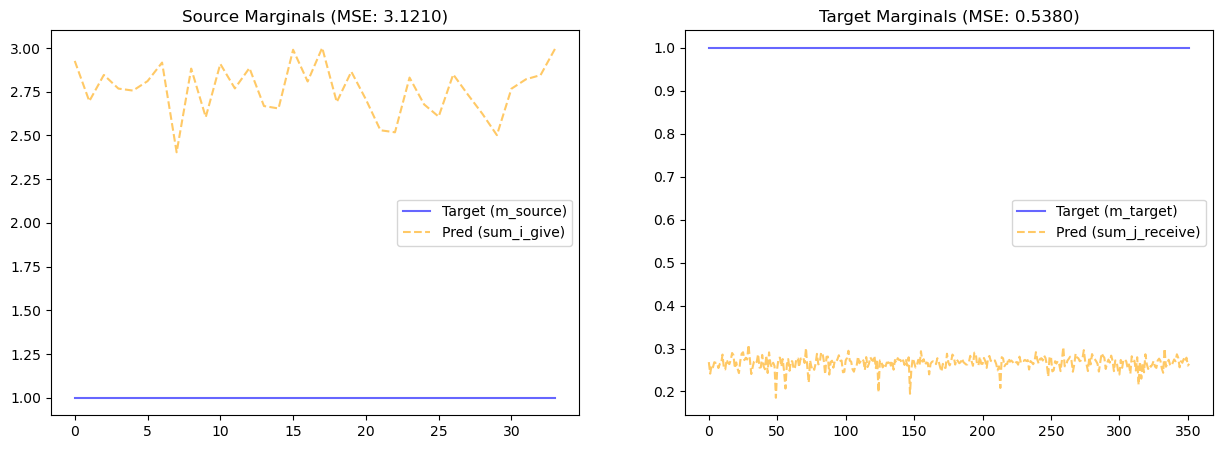

 90%|█████████ | 9/10 [00:02<00:00,  3.42it/s]

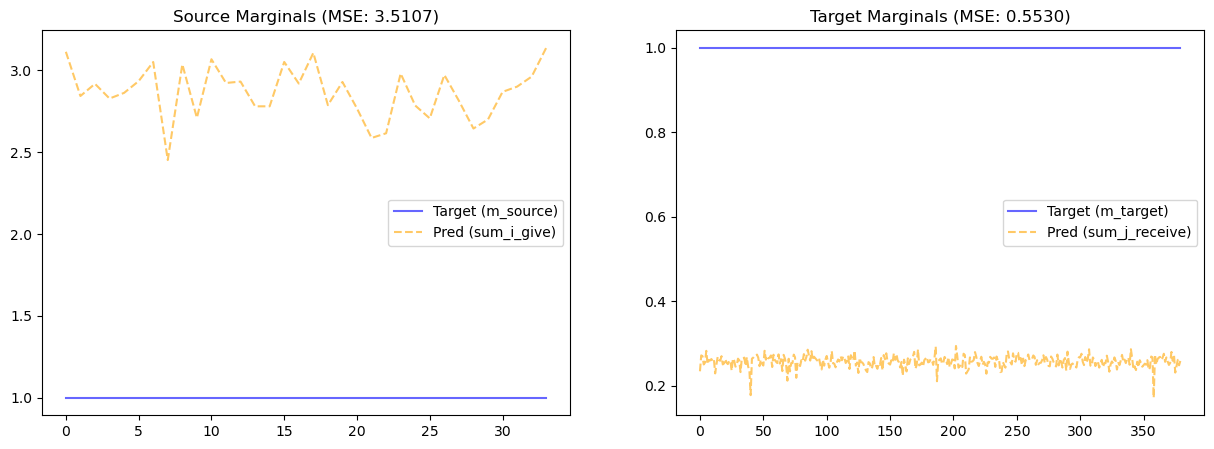

100%|██████████| 10/10 [00:03<00:00,  3.19it/s]


Batch saved: 10/16


  0%|          | 0/6 [00:00<?, ?it/s]

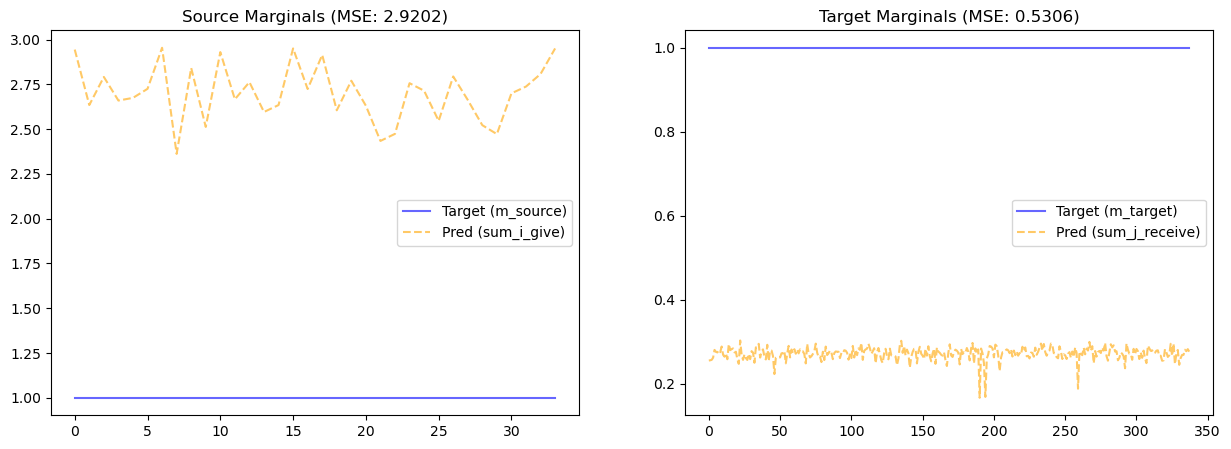

 17%|█▋        | 1/6 [00:00<00:01,  3.04it/s]

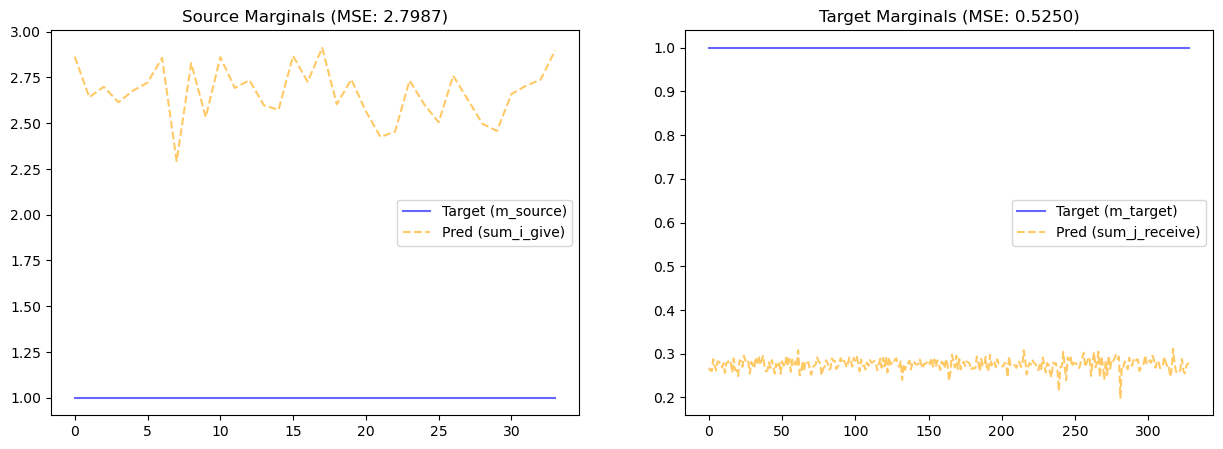

 33%|███▎      | 2/6 [00:00<00:01,  3.01it/s]

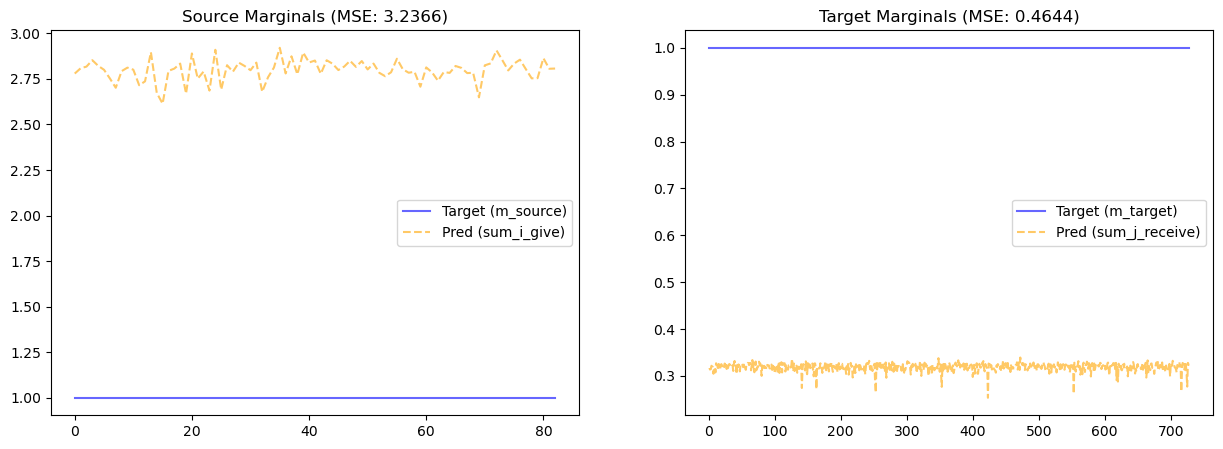

 50%|█████     | 3/6 [00:01<00:01,  2.64it/s]

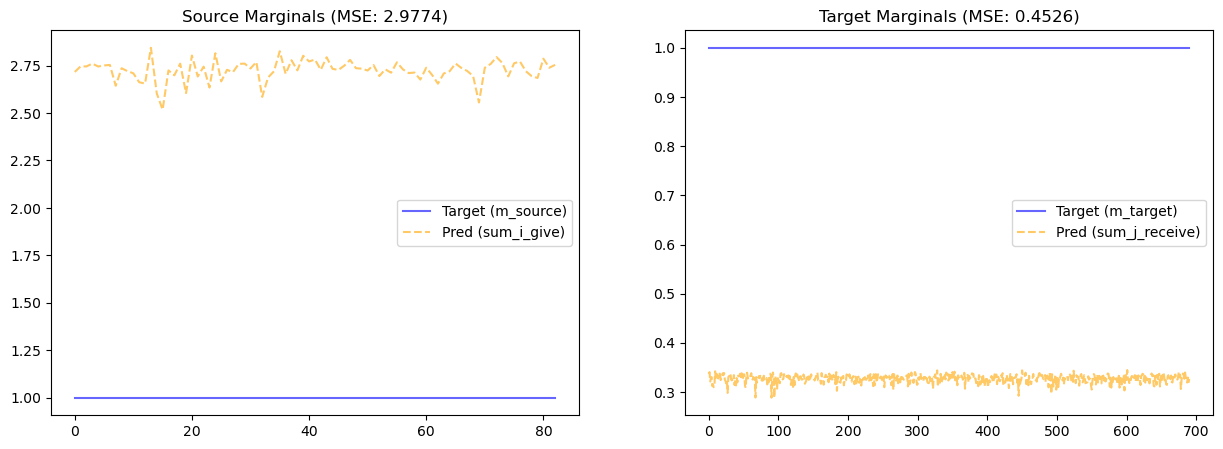

 67%|██████▋   | 4/6 [00:01<00:00,  2.67it/s]

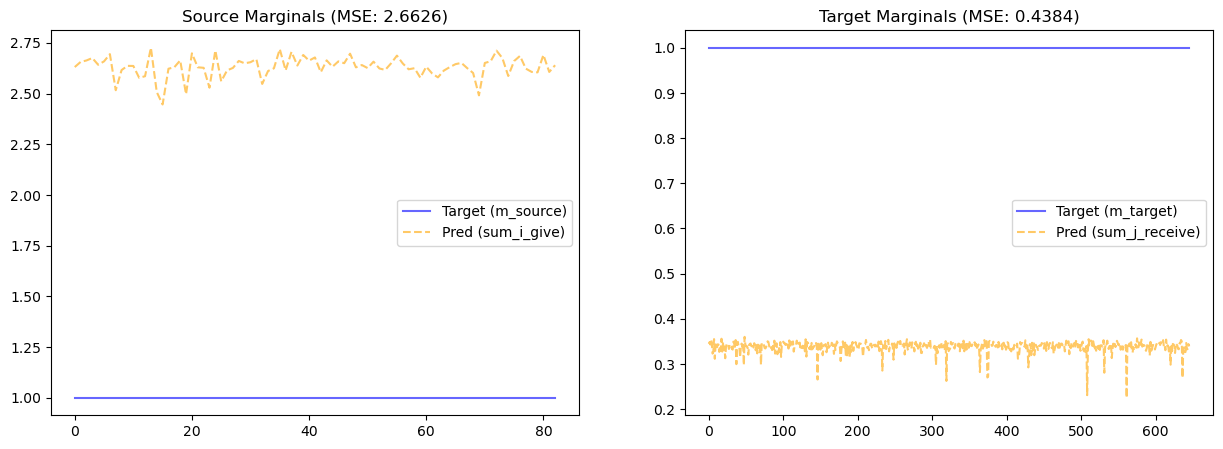

 83%|████████▎ | 5/6 [00:01<00:00,  2.68it/s]

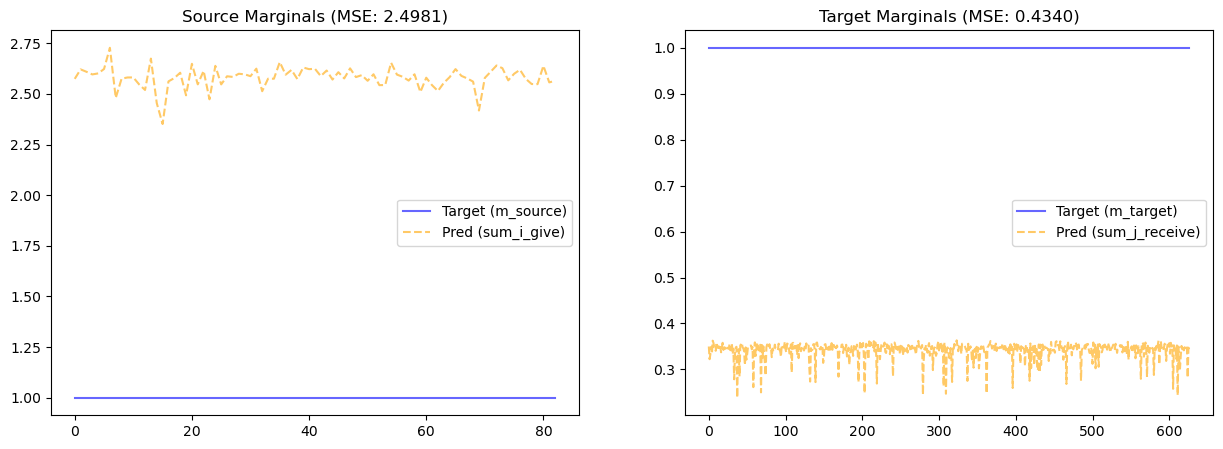

100%|██████████| 6/6 [00:02<00:00,  2.73it/s]


Batch saved: 16/16
合并所有batch...
完成！最终结果: ./experiments/ot_plan/ot_precompute_Sciplex3_test_42_0.2_True_X_pca_100_None_delta12_regm1_train.pkl


100%|██████████| 10/10 [00:00<00:00, 16.09it/s]


Batch saved: 10/16


100%|██████████| 6/6 [00:00<00:00, 12.44it/s]


Batch saved: 16/16
合并所有batch...
完成！最终结果: ./experiments/ot_plan/ot_precompute_Sciplex3_test_42_0.2_True_X_pca_100_None_delta12_regm1_test.pkl


In [38]:
delta = 12
reg_m = 1
use_mini_batch_uot = False
group_number = 10
ot_origin = f"delta{delta}_regm{reg_m}"
save_path_train = f"./experiments/ot_plan/ot_precompute_{data_origin_ot}_{ot_origin}_train.pkl"
save_path_test = f"./experiments/ot_plan/ot_precompute_{data_origin_ot}_{ot_origin}_test.pkl"

load_saved = True
if os.path.exists(save_path_train) and load_saved:
    print(f"read{save_path_train}")
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep, 
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            batch_save_size=10,
                            draw = True)

if os.path.exists(save_path_test) and load_saved:
    print(f"read{save_path_test}")
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep, 
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

n_iterations = 200

load_experiment = False # 如果是False可以无视下面三个参数
experiment_load_path = "experiments/exp_20260224_155124_PBMC_donor11_hvg_42_0.4_False_X_pca_scaled_100_False_delta10_regm1"
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_20000.pt") 

cov_config = adata_train.uns.get('cov_config', {})
covariate_info = adata_train.uns.get('covariate_info', {})


if not load_experiment:
    experiment_save_path = os.path.join("experiments", f"exp_{timestamp}_{data_origin}_{ot_origin}")
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")
    os.makedirs(checkpoint_save_path, exist_ok=True)
    
    config = {
        "in_out_dim": adata_control.obsm[sample_rep].shape[1],
        "condition_dim": adata_train.obsm[condition_rep_keys].shape[1],
        
        "hidden_dim_v": 1024,   
        "hidden_dim_g": 128,
        "n_hiddens_v": 12,
        "n_hiddens_g": 8,
    
        "con_embedding_dim": 512,
        "hidden_dim_con": 1024,
        
        "time_dim": 1024,
        "time_embedding_dim": 256,
        "hidden_dim_time": 512,

        "cov_emb_dim": 64, 
        
        "bottle_dim": 256,
        "activation": 'SiLU',
        
        "batch_size_per_condition": 2,  
        "batch_size_condition":1,
        "learning_rate": 1e-4,  
        "dropout": 0.1,
        "weight_decay":1e-4,
        "eta_min":5e-5,
        "seed": 42,
        "eval_interval":10,
    }
    config_save_path = f"{experiment_save_path}/config.yaml"
    with open(config_save_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        print(f"config saved to {config_save_path}")
else:
    with open(config_load_path, 'r') as f:
        config = yaml.safe_load(f)
        print(f"load saved_config from {config_load_path}")

    experiment_save_path = experiment_load_path  #直接继续某一个实验
    checkpoint_save_path = os.path.join(experiment_save_path, "checkpoints")


model = FNet(
    in_out_dim=config["in_out_dim"], 
    cov_config=cov_config, 
    covariate_info=covariate_info, 
    hidden_dim_v=config["hidden_dim_v"], 
    n_hiddens_v=config["n_hiddens_v"], 
    hidden_dim_g=config["hidden_dim_g"], 
    n_hiddens_g=config["n_hiddens_g"], 
    condition_dim=config["condition_dim"], 
    con_embedding_dim=config["con_embedding_dim"], 
    hidden_dim_con=config["hidden_dim_con"], 
    time_dim=config["time_dim"], 
    time_embedding_dim=config["time_embedding_dim"], 
    hidden_dim_time=config["hidden_dim_time"], 
    bottle_dim=config["bottle_dim"], 
    cov_emb_dim=config.get("cov_emb_dim", 64), 
    dropout=config["dropout"], 
    activation=config["activation"]
)

model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=config["eta_min"])
seed_everything(config["seed"])

if load_experiment:    
    if os.path.exists(model_load_path):
        checkpoint = torch.load(model_load_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(f"load model from {model_load_path}")
    else:
        print("wrong model_load_path")

print("setup complete")

cpu
config saved to experiments/exp_20260320_201538_Sciplex3_test_42_0.2_True_X_pca_100_None_delta12_regm1/config.yaml
Global seed set to 42
setup complete


In [50]:
model_save_path = os.path.join(checkpoint_save_path, "test_11")
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                cov_config=cov_config,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = config["batch_size_per_condition"],
                batch_size_condition = config["batch_size_condition"],
                sample_rep = sample_rep,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=model_save_path,
                eval_interval = config["eval_interval"],
                save_interval = 5000, #每隔多少轮保存一次
                save_only_last = True) # 是否只保留最后的pt文件


正在构建局部到全局的索引映射...
data_loaded
正在构建局部到全局的索引映射...
data_loaded


Begin flow and growth matching...: 100%|██████████| 200/200 [00:12<00:00, 16.66epoch/s, loss=26.506, vloss=6.359, gloss=20.147, test_loss=0.827, test_vloss=0.785, test_gloss=0.042]


In [31]:
model_save_path

'experiments/exp_20260311_113942_PBMC_donor11_hvg2000_e5test3_42_0.2_True_X_scVI_512_None_delta20_regm1/checkpoints/test_11'

In [6]:
model_save_path = "experiments/exp_20260219_213059_PBMC_donor11_hvg_42_0.4_False_X_pca_scaled_100_delta10_regm1/checkpoints/test"

训练步数: 20000
最后一步 Loss: 0.787895
最后一步 vLoss: 0.783615
最后一步 gLoss: 0.004280
最后一步 test_Loss: 0.908057
最后一步 test_vLoss: 0.884642
最后一步 test_gLoss: 0.023416


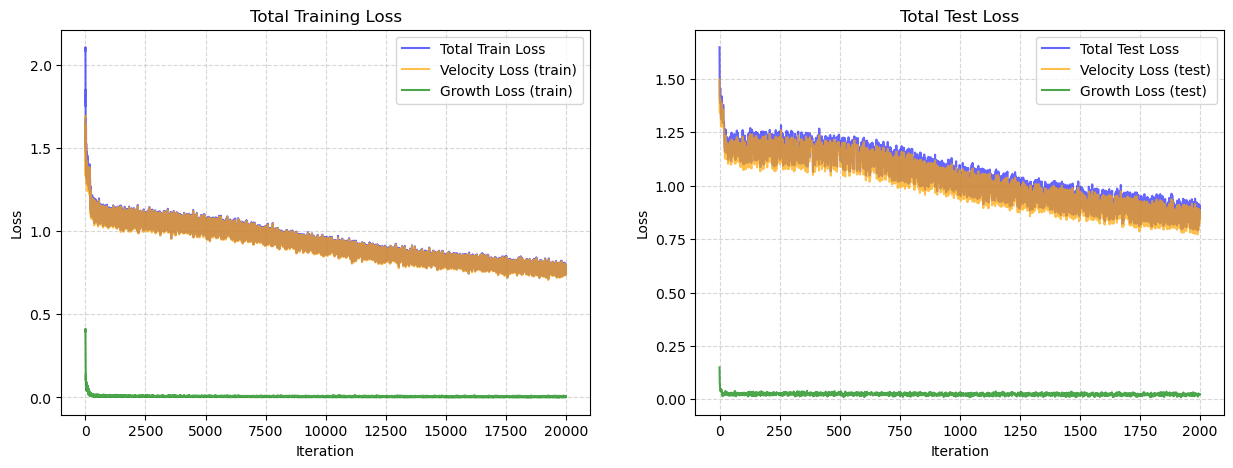

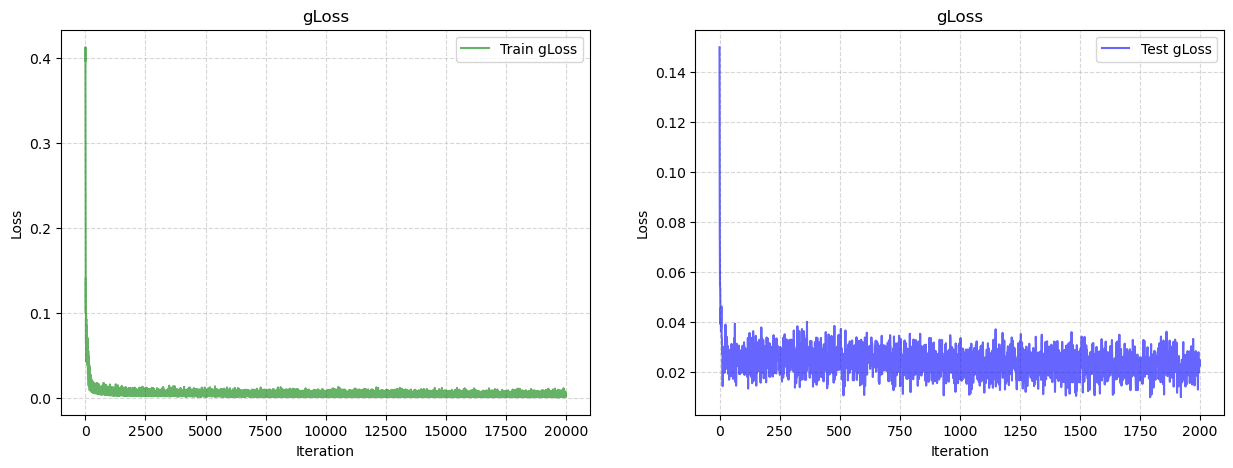

In [16]:
from src.evaluate import draw_loss
load_path = f"{model_save_path}_epoch_20000.pt"
draw_loss(load_path,eval_interval = 10,cut = 100,save_path = None) # cut代表去掉前多少个epoch 避免前期loss过大影响观察